In [ ]:
!pip install numpy scipy
!pip install control

# 1. Aproximación de función de transferencia por Python

El orden obtenido es n = 2
Función de transferencia del filtro Chebyshev:
Numerador:  [16420899.35090685        0.                0.        ]
Denominador:  [1.00000000e+00 5.08000167e+03 9.58572335e+07 2.00550427e+11
 1.55854546e+15]

Secciones de segundo orden (SOS):
Seccion 1:
Numerador: 16420899.350906845
Denominador: 1.0 3184.426319936705 66320820.24409301
 
Seccion 2:
Numerador: 1.0
Denominador: 1.0 1895.5753506375795 23500093.195588183
 


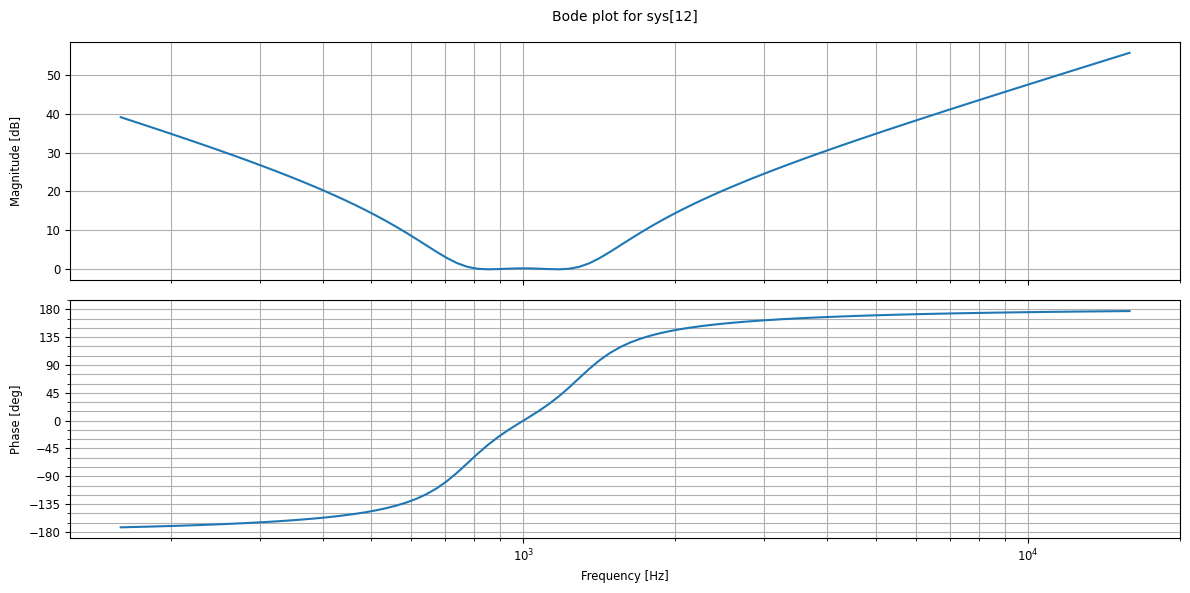

Las Función de Transferencia es: 

<TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


                     1.642e+07 s^2
--------------------------------------------------------
s^4 + 5080 s^3 + 9.586e+07 s^2 + 2.006e+11 s + 1.559e+15



In [ ]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
from scipy import signal

fp=[800, 1250]    # BANDA DE PASO [Hz]
fs=[200, 5000]    # BANDA DE RECHAZO [Hz]

As=30     # Atenuación en la BANDA DE RECHAZO [dB]
Ap=0.25   # Atenuación en la BANDA DE PASO [dB]

# Convertir frecuencias a radianes por segundo
Wp = 2 * np.pi * np.array(fp)  # Banda de paso [rad/s]
Ws = 2 * np.pi * np.array(fs)  # Banda de rechazo [rad/s]

# Calcular el orden del filtro y frecuencia normalizada
n, Wp_norm = signal.cheb1ord(Wp, Ws, Ap, As, analog=True)
print(f'El orden obtenido es n = {n}')

# Diseñar el filtro Chebyshev Tipo I
num, den = signal.cheby1(n, Ap, Wp_norm, btype='bandpass', analog=True, fs=None)

# Mostrar la función de transferencia
print("Función de transferencia del filtro Chebyshev:")
print("Numerador: ", num)
print("Denominador: ", den)

# Crear la función de transferencia
filtro = signal.TransferFunction(num, den)

# Convertir la función de transferencia en secciones de segundo orden (SOS)
sos = signal.tf2sos(num, den)
print("\nSecciones de segundo orden (SOS):")
cont=1
for transfunction in sos:
  print(f"Seccion {cont}:")
  print(f"Numerador: {transfunction[0]}")
  print(f"Denominador: {transfunction[3]} {transfunction[4]} {transfunction[5]}")
  print(" ")
  cont=cont+1
FiltroGraf= ctrl.TransferFunction(den,num)

omega = np.logspace(3,5,100)
plt.figure(figsize=(12,6))
ctrl.bode_plot(FiltroGraf,omega,dB=True,Hz=True)
plt.show()

print("Las Función de Transferencia es: \n")
print(ctrl.TransferFunction(num,den))

# 1.1 Realimentacion Negativa

In [ ]:
import sympy as sp
# Definimos las variables simbolicas
V2, Vo, Vi, C1, C2, R1, R2, R3, s, k = sp.symbols('V2 Vo Vi C1 C2 R1 R2 R3 s k')
# Definimos las ecuaciones
eq1 = V2 * (C1 * s + C2 * s + 1/R2 + 1/R1) - Vo/R2 - Vi/R1 - (C2 * Vo * s)/k
eq2 = (Vo * (C2 * s + 1/R3)) / k - C2 * V2 * s
# Resolver el sistema de ecuaciones para V2 y Vo
solucion = sp.solve([eq1, eq2], (V2, Vo))
# Extraer la solucion para Vo
Vo_sol = solucion[Vo]
# Simplificar la expresion de Vo/Vi
funcion_transferencia = sp.simplify(Vo_sol / Vi)
# Manipular la funcion de transferencia para que tenga la forma deseada
# Dividimos numerador y denominador por el coeficiente de s^2 en el denominador
coeficiente_s2 = C1 * C2 * R1 * R2 * R3
# Simplificar nuevamente
funcion_transferencia = sp.simplify(funcion_transferencia/coeficiente_s2)
# Mostrar la funcion de transferencia
print("Funcion de transferencia Vo/Vi:")
sp.pretty_print(funcion_transferencia)

Funcion de transferencia Vo/Vi:
                                                 k⋅s                           ↪
────────────────────────────────────────────────────────────────────────────── ↪
      ⎛                2                                                       ↪
C₁⋅R₁⋅⎝C₁⋅C₂⋅R₁⋅R₂⋅R₃⋅s  + C₁⋅R₁⋅R₂⋅s + C₂⋅R₁⋅R₂⋅s - C₂⋅R₁⋅R₃⋅k⋅s + C₂⋅R₁⋅R₃⋅s ↪

↪                         
↪ ────────────────────────
↪                        ⎞
↪  + C₂⋅R₂⋅R₃⋅s + R₁ + R₂⎠


# 1.2 Realimentacion Positiva

In [ ]:
import sympy as sp

# Definimos las variables simbólicas
V2, Vo, Vi, C1, C2, R1, R2, R3, s, k = sp.symbols('V2 Vo Vi C1 C2 R1 R2 R3 s k')

# Definimos las ecuaciones
eq1 = V2 * (C1 * s + C2 * s + 1/R2 + 1/R1) - Vo/R2 - Vi/R1 - (C2 * Vo * s)/k
eq2 = (Vo * (C2 * s + 1/R3)) / k - C2 * V2 * s

# Resolver el sistema de ecuaciones para V2 y Vo
solucion = sp.solve([eq1, eq2], (V2, Vo))

# Extraer la solución para Vo
Vo_sol = solucion[Vo]

# Simplificar la expresión de Vo/Vi
funcion_transferencia = sp.simplify(Vo_sol / Vi)

# Manipular la función de transferencia para que tenga la forma deseada
# Dividimos numerador y denominador por el coeficiente de s^2 en el denominador
coeficiente_s2 = C1 * C2 * R1 * R2 * R3

# Simplificar nuevamente
funcion_transferencia = sp.simplify(funcion_transferencia/coeficiente_s2)

print(funcion_transferencia)
# Mostrar la función de transferencia
print("Función de transferencia Vo/Vi:")
sp.pretty_print(funcion_transferencia)

print("Según FT de requerimiento: ")
k1 = k/(C1*R1)
a1 = 1/(C2*R3) + 1/(C2*R3)

k*s/(C1*R1*(C1*C2*R1*R2*R3*s**2 + C1*R1*R2*s + C2*R1*R2*s - C2*R1*R3*k*s + C2*R1*R3*s + C2*R2*R3*s + R1 + R2))
Función de transferencia Vo/Vi:
                                                 k⋅s                           ↪
────────────────────────────────────────────────────────────────────────────── ↪
      ⎛                2                                                       ↪
C₁⋅R₁⋅⎝C₁⋅C₂⋅R₁⋅R₂⋅R₃⋅s  + C₁⋅R₁⋅R₂⋅s + C₂⋅R₁⋅R₂⋅s - C₂⋅R₁⋅R₃⋅k⋅s + C₂⋅R₁⋅R₃⋅s ↪

↪                         
↪ ────────────────────────
↪                        ⎞
↪  + C₂⋅R₂⋅R₃⋅s + R₁ + R₂⎠
Según FT de requerimiento: 


# 2. Definicion Componentes

Realimentación Positiva

In [ ]:
import sympy as sp

# Definir las variables simbólicas
k, R ,C= sp.symbols('k R C')
C=100e-9 # defino a C en 100 nF

# Ecuaciones simplificadas
eq1 = -k/(C*R) + 4/(C*R) - 3184.42
eq2 = 2/(C*2*R*2) - 66320656

# Resolver el sistema de ecuaciones
R =sp.solve(eq2,R) # defino el valor de R
print(R)
R=R[0]
eq1 = -k/(C*R) + 4/(C*R) - 3184.42 # redefino la ecuación para el nuevo valor de R
K, =sp.solve(eq1,k) # como es cuadrática obtendré un valor positivo y otro negativo

# Mostrar la solución
print("Solución del sistema de ecuaciones Realimentación Positiva:")
print(f"k = {K}")
print(f"R = {R}")

[0.0753912928726157]
Solución del sistema de ecuaciones Realimentación Positiva:
k = 3.99997599224592
R = 0.0753912928726157


# 4. Filtro Final - Inversor

In [ ]:
atenuacion=29.5 # Hz
# ganancia
atte=10**(atenuacion/20)
# inversa de la atenuacion
k=1/atte
# defino una de las resistencias
R1=100e3
# caculo la segunda resistencia
R2=R1*k
print(f"atenuacion={atte} k={k}")
print(f"R_1={R1} R_2={R2}")

atenuacion=29.853826189179603 k=0.03349654391578276
R_1=100000.0 R_2=3349.654391578276


# 6. Sensibilidad

In [ ]:
import numpy as np

def calcular_sensibilidades_sallen_key(R1, R2, R3, C1, C2, k):
    # Sensibilidades para ωp
    S_R1_wp = -0.5 * R2 / (R1 + R2)
    S_R2_wp = -0.5 * R1 / (R1 + R2)
    S_R3_wp = -0.5
    S_C1_wp = -0.5
    S_C2_wp = -0.5

    # Cálculo de bw_p (ancho de banda)
    bw_p = (1/(R2*C1))*(1 - k) + (1/(R1*C1)) + (1/(R3*C1)) + (1/(R3*C2))

    # Sensibilidades para bw_p
    S_R1_bwp = (-1/(C1*R1)) / bw_p
    S_R2_bwp = (-(1 - k)/(C1*R2)) / bw_p
    S_R3_bwp = (-(C1 + C2)/(C1*C2*R3)) / bw_p
    S_C1_bwp = (-(R1*R2 + R1*R3*(1 - k) + R2*R3)/(C1*R1*R2*R3)) / bw_p
    S_C2_bwp = (-1/(C2*R3)) / bw_p

    return {
        'ωp': {
            'R1': S_R1_wp,
            'R2': S_R2_wp,
            'R3': S_R3_wp,
            'C1': S_C1_wp,
            'C2': S_C2_wp
        },
        'bwp': {
            'R1': S_R1_bwp,
            'R2': S_R2_bwp,
            'R3': S_R3_bwp,
            'C1': S_C1_bwp,
            'C2': S_C2_bwp
        }
    }

def calcular_sensibilidades_realimentacion_negativa(R1, R2, C1, C2):
    # Sensibilidades para ωp (todas iguales)
    S_R1_wp = -0.5
    S_R2_wp = -0.5
    S_C1_wp = -0.5
    S_C2_wp = -0.5

    # Cálculo de bw_p (ancho de banda)
    bw_p = (1/(R2*C2)) + (1/(R2*C1))

    # Sensibilidades para bw_p
    S_R1_bwp = 0
    S_R2_bwp = -1
    S_C1_bwp = -C2 / (C1 + C2)
    S_C2_bwp = -C1 / (C1 + C2)

    return {
        'ωp': {
            'R1': S_R1_wp,
            'R2': S_R2_wp,
            'C1': S_C1_wp,
            'C2': S_C2_wp
        },
        'bwp': {
            'R1': S_R1_bwp,
            'R2': S_R2_bwp,
            'C1': S_C1_bwp,
            'C2': S_C2_bwp
        }
    }

def verificar_identidades(sensibilidades, tipo_circuito):

    if tipo_circuito == 'sallen_key':
        # Verificación para ωp
        suma_R = sensibilidades['ωp']['R1'] + sensibilidades['ωp']['R2'] + sensibilidades['ωp']['R3']
        suma_C = sensibilidades['ωp']['C1'] + sensibilidades['ωp']['C2']
        print(f"Suma sensibilidades R para ωp: {suma_R} (debe ser -1)")
        print(f"Suma sensibilidades C para ωp: {suma_C} (debe ser -1)")
        print(f"Delta_w_p/w_p = {0.1*(suma_R+suma_C)}")

        # Verificación para Qp (calculado a partir de ωp y bw_p)
        # Qp = ωp / bw_p, entonces S_x^Qp = S_x^ωp - S_x^bwp
        S_R1_bwp = sensibilidades['bwp']['R1']
        S_R2_bwp = sensibilidades['bwp']['R2']
        S_R3_bwp = sensibilidades['bwp']['R3']
        S_C1_bwp = sensibilidades['bwp']['C1']
        S_C2_bwp = sensibilidades['bwp']['C2']

        suma_R_bwp = S_R1_bwp + S_R2_bwp + S_R3_bwp
        suma_C_bwp = S_C1_bwp + S_C2_bwp
        print(f"Suma sensibilidades R para Qp: {suma_R_bwp} (debe ser 0)")
        print(f"Suma sensibilidades C para Qp: {suma_C_bwp} (debe ser 0)")
        print(f"Delta_w_p/w_p = {0.1*(suma_R_bwp+suma_C_bwp)}")

    elif tipo_circuito == 'negativa':
        # Verificación para ωp
        suma_R = sensibilidades['ωp']['R1'] + sensibilidades['ωp']['R2']
        suma_C = sensibilidades['ωp']['C1'] + sensibilidades['ωp']['C2']
        print(f"Suma sensibilidades R para ωp: {suma_R} (debe ser -1)")
        print(f"Suma sensibilidades C para ωp: {suma_C} (debe ser -1)")
        print(f"Delta_w_p/w_p = {0.1*(suma_R+suma_C)}")
        # Verificación para Qp
        S_R1_bwp =sensibilidades['bwp']['R1']
        S_R2_bwp =sensibilidades['bwp']['R2']
        S_C1_bwp =sensibilidades['bwp']['C1']
        S_C2_bwp =sensibilidades['bwp']['C2']

        suma_R_bwp = S_R1_bwp + S_R2_bwp
        suma_C_bwp = S_C1_bwp + S_C2_bwp
        print(f"Suma sensibilidades R para Qp: {suma_R_bwp} (debe ser 0)")
        print(f"Suma sensibilidades C para Qp: {suma_C_bwp} (debe ser 0)")
        print(f"Delta_bw_p/bw_p = {0.1*(suma_R_bwp+suma_C_bwp)}")
# Ejemplo de uso con los valores del documento

print("====== Sensibilidades para Realimentación Positiva ======")
R1_sk = 1738
R2_sk = 1738
R3_sk = 1738
C1_sk = 100e-9
C2_sk = 100e-9
k_sk = 3.44

sens_sk = calcular_sensibilidades_sallen_key(R1_sk, R2_sk, R3_sk, C1_sk, C2_sk, k_sk)
print("\nSensibilidades para ωp:")
for comp, valor in sens_sk['ωp'].items():
  print(f"S_{comp}^ωp = {valor:.4f}")

print("\nSensibilidades para bw_p:")
for comp, valor in sens_sk['bwp'].items():
    print(f"S_{comp}^bwp = {valor:.4f}")

print("\nVerificación de identidades:")
verificar_identidades(sens_sk, 'sallen_key')

print("\n====== Sensibilidades para realimentación negativa ======")
R1_rn = 410
R2_rn = 10560
C1_rn = 100e-9
C2_rn = 100e-9

sens_rn = calcular_sensibilidades_realimentacion_negativa(R1_rn, R2_rn, C1_rn, C2_rn)
print("\nSensibilidades para ωp:")
for comp, valor in sens_rn['ωp'].items():
    print(f"S_{comp}^ωp = {valor:.4f}")

print("\nSensibilidades para bw_p:")
for comp, valor in sens_rn['bwp'].items():
    print(f"S_{comp}^bwp = {valor:.4f}")

print("\nVerificación de identidades:")
verificar_identidades(sens_rn, 'negativa')

====== Sensibilidades para Realimentación Positiva ======

Sensibilidades para ωp:
S_R1^ωp = -0.2500
S_R2^ωp = -0.2500
S_R3^ωp = -0.5000
S_C1^ωp = -0.5000
S_C2^ωp = -0.5000

Sensibilidades para bw_p:
S_R1^bwp = -1.7857
S_R2^bwp = 4.3571
S_R3^bwp = -3.5714
S_C1^bwp = 0.7857
S_C2^bwp = -1.7857

Verificación de identidades:
Suma sensibilidades R para ωp: -1.0 (debe ser -1)
Suma sensibilidades C para ωp: -1.0 (debe ser -1)
Delta_w_p/w_p = -0.2
Suma sensibilidades R para Qp: -1.0000000000000013 (debe ser 0)
Suma sensibilidades C para Qp: -1.0000000000000009 (debe ser 0)
Delta_w_p/w_p = -0.20000000000000023

====== Sensibilidades para realimentación negativa ======

Sensibilidades para ωp:
S_R1^ωp = -0.5000
S_R2^ωp = -0.5000
S_C1^ωp = -0.5000
S_C2^ωp = -0.5000

Sensibilidades para bw_p:
S_R1^bwp = 0.0000
S_R2^bwp = -1.0000
S_C1^bwp = -0.5000
S_C2^bwp = -0.5000

Verificación de identidades:
Suma sensibilidades R para ωp: -1.0 (debe ser -1)
Suma sensibilidades C para ωp: -1.0 (debe ser -1)
Del